Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported!')

Libraries imported!


Loading ML Results

In [7]:
path = r'C:\Users\nbush\OneDrive - University of Huddersfield\Desktop\FYP\preprocessed'

ml_results = pd.read_csv(
    f'{path}\\tabular_ml_results.csv',
    index_col=0  # ← Yeh add karo
)

# Index ko column mein convert karo
ml_results = ml_results.reset_index()
ml_results.columns.values[0] = 'Model'

print(' ML Results:')
print(ml_results)

 ML Results:
                 Model  Accuracy  F1-Score  ROC-AUC
0              XGBoost     94.88     94.87    94.39
1        Random Forest     92.79     92.70    94.46
2                  SVM     84.19     84.38    89.74
3  Logistic Regression     81.63     81.96    88.31


In [8]:
print(ml_results.columns.tolist())
print(ml_results.head())

['Model', 'Accuracy', 'F1-Score', 'ROC-AUC']
                 Model  Accuracy  F1-Score  ROC-AUC
0              XGBoost     94.88     94.87    94.39
1        Random Forest     92.79     92.70    94.46
2                  SVM     84.19     84.38    89.74
3  Logistic Regression     81.63     81.96    88.31


Loading DL Results

In [9]:
# CNN Results
cnn_results = pd.read_csv(f'{path}\\cnn_results.csv')

# VGG16 Results
vgg16_results = pd.read_csv(f'{path}\\vgg16_results.csv')

print('CNN Results:')
print(cnn_results)
print('\nVGG16 Results:')
print(vgg16_results)

CNN Results:
  Model  Accuracy  F1-Score  ROC-AUC
0   CNN     56.67     56.51     72.5

VGG16 Results:
   Model  Accuracy  F1-Score  ROC-AUC
0  VGG16     75.94     76.11    90.83


Complete Comparison Table

In [10]:
# ML results mein Dataset column add karo
ml_results['Dataset'] = 'Tabular'
ml_results['Type']    = 'Classical ML'

# CNN
cnn_results['Dataset'] = 'MRI Images'
cnn_results['Type']    = 'Deep Learning'

# VGG16
vgg16_results['Dataset'] = 'MRI Images'
vgg16_results['Type']    = 'Deep Learning'

# Sab combine karo
all_results = pd.concat([
    ml_results,
    cnn_results,
    vgg16_results
], ignore_index=True)

# Sort by Accuracy
all_results = all_results.sort_values(
    'Accuracy', ascending=False
).reset_index(drop=True)

print('=' * 65)
print('    COMPLETE MODEL COMPARISON — ALL MODELS')
print('=' * 65)
print(all_results[['Model', 'Dataset', 'Type',
                   'Accuracy', 'F1-Score', 
                   'ROC-AUC']].to_string(index=False))
print('=' * 65)
print(f'\n Best Model: {all_results.iloc[0]["Model"]}')
print(f'   Accuracy  : {all_results.iloc[0]["Accuracy"]}%')

    COMPLETE MODEL COMPARISON — ALL MODELS
              Model    Dataset          Type  Accuracy  F1-Score  ROC-AUC
            XGBoost    Tabular  Classical ML     94.88     94.87    94.39
      Random Forest    Tabular  Classical ML     92.79     92.70    94.46
                SVM    Tabular  Classical ML     84.19     84.38    89.74
Logistic Regression    Tabular  Classical ML     81.63     81.96    88.31
              VGG16 MRI Images Deep Learning     75.94     76.11    90.83
                CNN MRI Images Deep Learning     56.67     56.51    72.50

 Best Model: XGBoost
   Accuracy  : 94.88%


Comparison Bar Chart

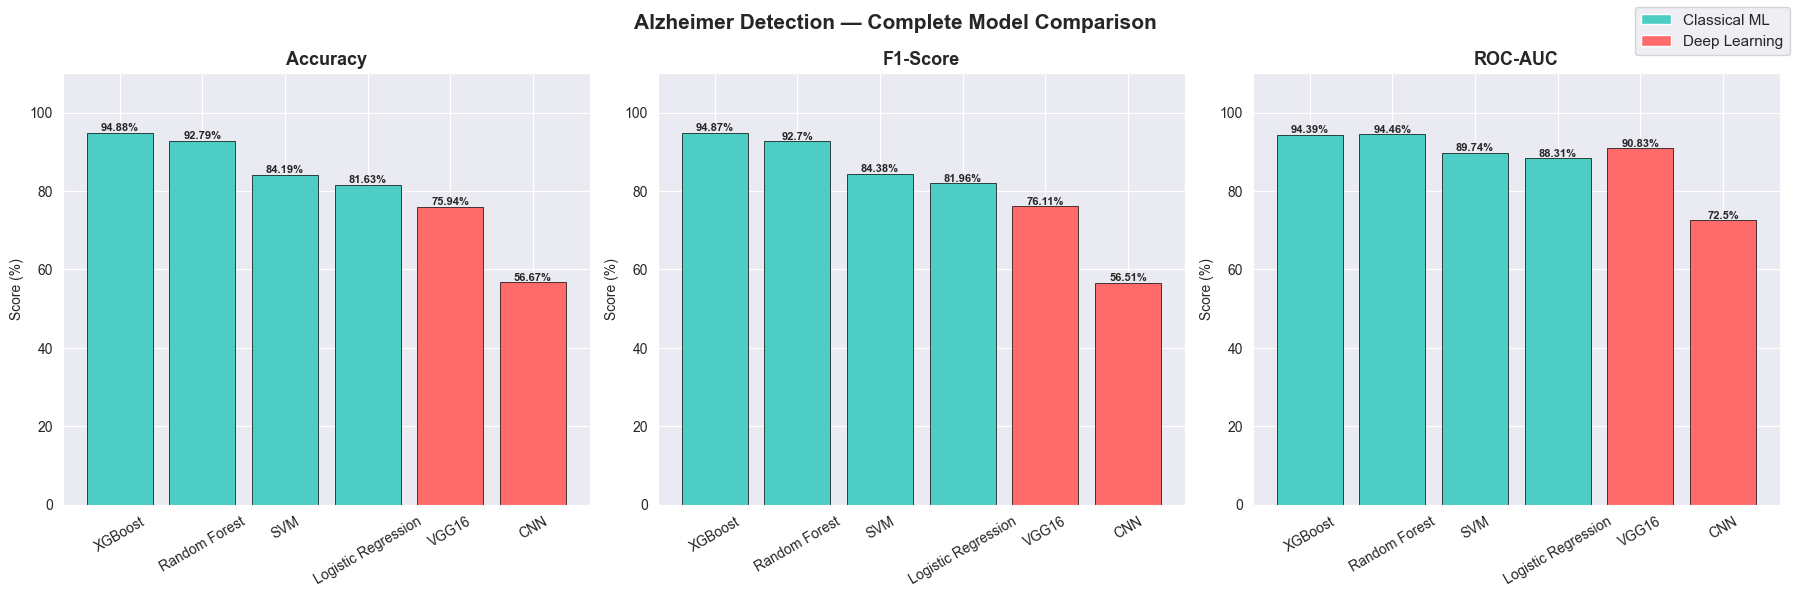

 Comparison chart saved!


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = ['Accuracy', 'F1-Score', 'ROC-AUC']
colors = {
    'Classical ML' : '#4ECDC4',
    'Deep Learning': '#FF6B6B'
}

# ← Yeh line add karo
model_names = all_results['Model'].astype(str).tolist()

for idx, metric in enumerate(metrics):
    bars = axes[idx].bar(
        model_names,  # ← 'all_results['Model']' ki jagah
        all_results[metric],
        color=[colors[t] for t in all_results['Type']],
        edgecolor='black',
        linewidth=0.5
    )

    axes[idx].set_title(metric,
                        fontsize=13,
                        fontweight='bold')
    axes[idx].set_ylabel('Score (%)')
    axes[idx].set_ylim(0, 110)
    axes[idx].tick_params(axis='x',
                          rotation=30)

    for bar, val in zip(bars, all_results[metric]):
        axes[idx].text(
            bar.get_x() + bar.get_width()/2.,
            bar.get_height() + 0.5,
            f'{val}%',
            ha='center',
            fontsize=8,
            fontweight='bold'
        )

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4ECDC4', label='Classical ML'),
    Patch(facecolor='#FF6B6B', label='Deep Learning')
]
fig.legend(handles=legend_elements,
           loc='upper right',
           fontsize=11)

plt.suptitle(
    'Alzheimer Detection — Complete Model Comparison',
    fontsize=15,
    fontweight='bold'
)
plt.tight_layout()
plt.savefig('complete_comparison.png',
            dpi=150,
            bbox_inches='tight')
plt.show()
print(' Comparison chart saved!')

Tabular VS Image Comparison 

Tabular vs Image — Average Performance:
  Metric  Tabular ML (Avg)  Image DL (Avg)
Accuracy             88.37           66.31
F1-Score             88.48           66.31
 ROC-AUC             91.72           81.66


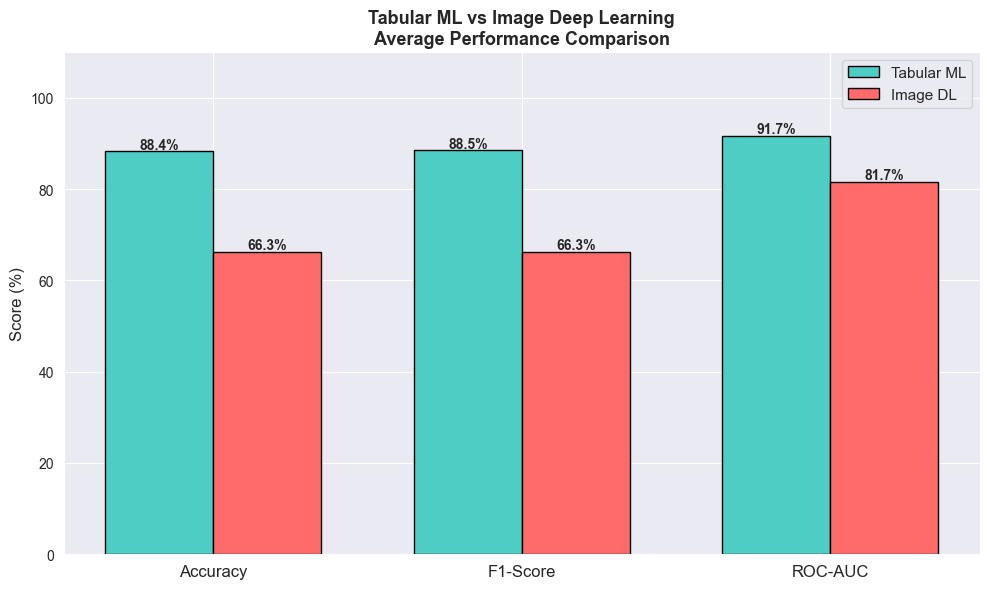

Chart saved!


In [12]:
# Average performance
tabular_avg = ml_results[['Accuracy',
                           'F1-Score',
                           'ROC-AUC']].mean()
image_avg = pd.concat([cnn_results,
                        vgg16_results])[['Accuracy',
                                         'F1-Score',
                                         'ROC-AUC']].mean()

comparison = pd.DataFrame({
    'Metric'          : ['Accuracy',
                         'F1-Score',
                         'ROC-AUC'],
    'Tabular ML (Avg)': tabular_avg.values.round(2),
    'Image DL (Avg)'  : image_avg.values.round(2)
})

print('Tabular vs Image — Average Performance:')
print(comparison.to_string(index=False))

# Chart
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(comparison['Metric']))
width = 0.35

bars1 = ax.bar(x - width/2,
               comparison['Tabular ML (Avg)'],
               width,
               label='Tabular ML',
               color='#4ECDC4',
               edgecolor='black')
bars2 = ax.bar(x + width/2,
               comparison['Image DL (Avg)'],
               width,
               label='Image DL',
               color='#FF6B6B',
               edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(comparison['Metric'],
                   fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_ylim(0, 110)
ax.legend(fontsize=11)
ax.set_title(
    'Tabular ML vs Image Deep Learning\n'
    'Average Performance Comparison',
    fontsize=13,
    fontweight='bold'
)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2.,
            bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%',
            ha='center',
            fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2.,
            bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%',
            ha='center',
            fontweight='bold')

plt.tight_layout()
plt.savefig('tabular_vs_image.png',
            dpi=150,
            bbox_inches='tight')
plt.show()
print('Chart saved!')

Heatmap

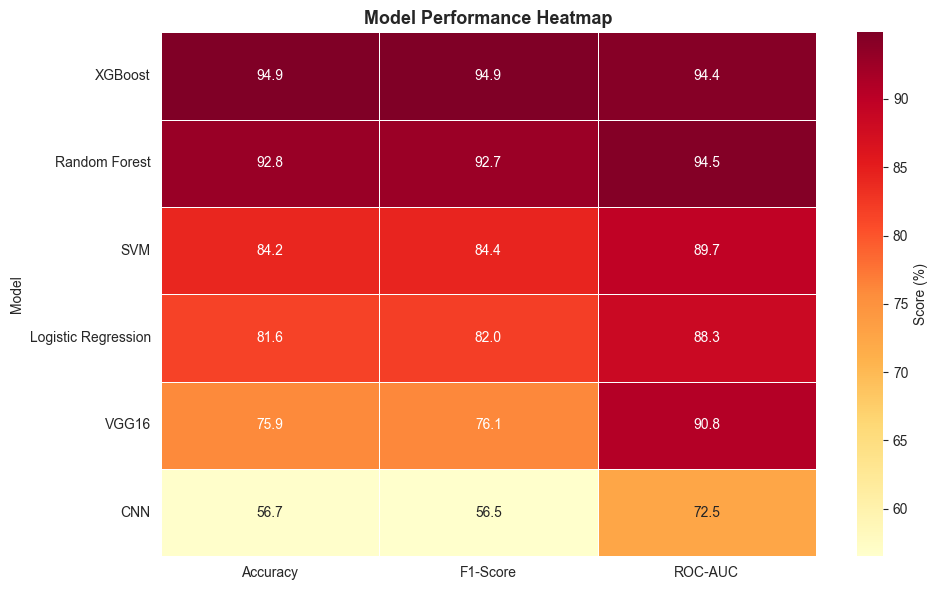

Heatmap saved!


In [13]:
plt.figure(figsize=(10, 6))

heatmap_data = all_results.set_index('Model')[
    ['Accuracy', 'F1-Score', 'ROC-AUC']
]

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Score (%)'}
)

plt.title(
    'Model Performance Heatmap',
    fontsize=13,
    fontweight='bold'
)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('performance_heatmap.png',
            dpi=150,
            bbox_inches='tight')
plt.show()
print('Heatmap saved!')

Final Summary

In [15]:
print('=' * 65)
print('          FINAL PROJECT SUMMARY')
print('=' * 65)
print(f'\n Total Models Evaluated : {len(all_results)}')
print(f' Tabular ML Models      : {len(ml_results)}')
print(f'  Image DL Models        : 2 (CNN + VGG16)')
print()
print(' Best Tabular Model:')
best_ml = ml_results.loc[
    ml_results['Accuracy'].idxmax()
]
print(f'   {best_ml["Model"]} — '
      f'{best_ml["Accuracy"]}% accuracy')
print()
print(' Best Image Model:')
print(f'   VGG16 — 75.94% accuracy')
print()
print(' Key Finding:')
print(f'   Tabular ML avg accuracy: '
      f'{tabular_avg["Accuracy"]:.2f}%')
print(f'   Image DL avg accuracy  : '
      f'{image_avg["Accuracy"]:.2f}%')
print()

if tabular_avg['Accuracy'] > image_avg['Accuracy']:
    print(' Classical ML on tabular data outperformed')
    print('   Deep Learning on MRI images!')
else:
    print(' Deep Learning on MRI images outperformed')
    print('   Classical ML on tabular data!')

print('=' * 65)
print(' Comparison Complete!')
print('Next → SHAP + Grad-CAM (XAI)!')

          FINAL PROJECT SUMMARY

 Total Models Evaluated : 6
 Tabular ML Models      : 4
  Image DL Models        : 2 (CNN + VGG16)

 Best Tabular Model:
   XGBoost — 94.88% accuracy

 Best Image Model:
   VGG16 — 75.94% accuracy

 Key Finding:
   Tabular ML avg accuracy: 88.37%
   Image DL avg accuracy  : 66.31%

 Classical ML on tabular data outperformed
   Deep Learning on MRI images!
 Comparison Complete!
Next → SHAP + Grad-CAM (XAI)!
